In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from astropy import units as u

from dsph_analysis import kinematic_io

In [29]:
# catalog_path = '/home/jupyter-tvnguyen/mock_catalogs/icrs/mock_data/MockA.csv'
catalog_path = './mock_data/MockA.csv'
meta = kinematic_io.load_meta('draco_1')
data = kinematic_io.load_kinematic_data(
    catalog_path,
    meta,
    source='mock_icrs',
    vlos_err_floor=0.0,
    apply_perspective_corr=True,
)

In [30]:
X_proj = data.X_proj.value
Y_proj = data.Y_proj.value
R_proj = data.R_proj.value
vlos = data.vlos.value
vlos_err = data.vlos_err.value

In [31]:
pd.DataFrame(vlos_err).to_csv("./mock_data/MockA_unc.csv", header=None, index=None)


In [5]:
np.testing.assert_almost_equal(R_proj, np.sqrt(X_proj**2 + Y_proj**2))

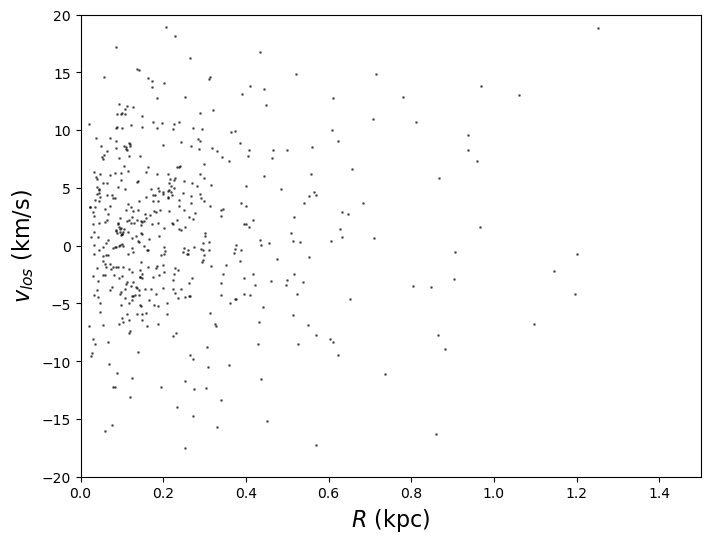

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(R_proj, vlos, s=1, color='k', alpha=0.5)
ax.set_xlim(0, 1.5)
ax.set_ylim(-20, 20)
ax.set_xlabel(r"$R$ (kpc)", fontsize=16)
ax.set_ylabel(r"$v_{los}$ (km/s)", fontsize=16)
# cbar.set_label("Number density", fontsize=16)
plt.show()